# PCA V3 — Eventos Tácticos F1
Lee `tactical_events_v3.parquet` (~515 variables) y aplica PCA completo.

Mejoras vs V2:
- Fuente: v3 con 515 vars vs 197 de v2
- Scree plot con línea de 90% de varianza
- Scatter coloreado por event_type Y por carrera
- Loadings para PC1..PC4 (no solo PC1/PC2)
- Heatmap de loadings top variables
- Biplot (vectores de variables + puntos de eventos)

In [6]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('dark_background')
sns.set_palette('husl')

BASE_DIR = '../F1-data-project/project/'
print('Librerías cargadas OK')

Librerías cargadas OK


In [7]:
# ==========================================
# 1. CARGA DEL V3
# ==========================================
file_path = f'../data/features/tactical_events_v3.parquet'
df = pl.read_parquet(file_path).to_pandas()

print(f'Eventos cargados : {len(df)}')
print(f'Columnas totales : {len(df.columns)}')
print(f'Tipos de evento  : {df["event_type"].value_counts().to_dict()}')
print(f'Carreras         : {df["race_name"].unique().tolist()}')

Eventos cargados : 643
Columnas totales : 540
Tipos de evento  : {'On_Track_Overtake': 584, 'Pit_Strategy': 59}
Carreras         : ['australia_2026', 'china_2026', 'japan_2026', 'united_states_2026']


In [8]:
# ==========================================
# 2. SEPARACIÓN METADATA vs FEATURES
# ==========================================
METADATA_COLS = [
    'event_id', 'race_name', 'lap_number', 'event_type',
    'attacker', 'defender', 'pos_change',
    'att_compound', 'def_compound'
]

# Encoding ordinal de compuesto (grip)
grip_map = {'SOFT': 3, 'MEDIUM': 2, 'HARD': 1, 'INTERMEDIATE': 0, 'WET': -1}
df['att_grip'] = df['att_compound'].map(grip_map)
df['def_grip'] = df['def_compound'].map(grip_map)
df['delta_grip'] = df['att_grip'] - df['def_grip']

# Separar
metadata = df[METADATA_COLS + ['att_grip', 'def_grip', 'delta_grip']].copy()
feature_cols = [c for c in df.columns if c not in METADATA_COLS + ['att_grip', 'def_grip']]
X_raw = df[feature_cols].select_dtypes(include='number').copy()

print(f'Features candidatas al PCA: {X_raw.shape[1]}')

Features candidatas al PCA: 498


In [9]:
# ==========================================
# 3. LIMPIEZA Y ESCALADO
# ==========================================

# Eliminar columnas con > 50% nulos
null_pct = X_raw.isnull().mean()
cols_ok  = null_pct[null_pct <= 0.5].index.tolist()
X_clean  = X_raw[cols_ok].copy()
print(f'Cols eliminadas (>50% nulos): {X_raw.shape[1] - len(cols_ok)}')

# Eliminar columnas con varianza 0 (constantes)
var_zero = X_clean.columns[X_clean.std() == 0].tolist()
X_clean  = X_clean.drop(columns=var_zero)
print(f'Cols eliminadas (varianza 0): {len(var_zero)}')

feature_cols_clean = X_clean.columns.tolist()
print(f'Features finales para PCA   : {len(feature_cols_clean)}')

# Imputar medianas
imputer  = SimpleImputer(strategy='median')
X_imp    = imputer.fit_transform(X_clean)

# Escalar
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols_clean)
print(f'Shape final escalado: {df_scaled.shape}')

Cols eliminadas (>50% nulos): 0
Cols eliminadas (varianza 0): 6
Features finales para PCA   : 492
Shape final escalado: (643, 492)


In [10]:
# ==========================================
# 4. PCA
# ==========================================
N_COMPONENTS = 15
pca   = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(df_scaled)

expl_var = pca.explained_variance_ratio_ * 100
cum_var  = np.cumsum(expl_var)

# Cuántos componentes para 80% y 90%
n_80 = next((i+1 for i,v in enumerate(cum_var) if v >= 80), N_COMPONENTS)
n_90 = next((i+1 for i,v in enumerate(cum_var) if v >= 90), N_COMPONENTS)

print(f'PC1 explica       : {expl_var[0]:.2f}%')
print(f'PC1+PC2 explican  : {cum_var[1]:.2f}%')
print(f'Componentes → 80% : {n_80}')
print(f'Componentes → 90% : {n_90}')

PC1 explica       : 26.08%
PC1+PC2 explican  : 35.86%
Componentes → 80% : 15
Componentes → 90% : 15


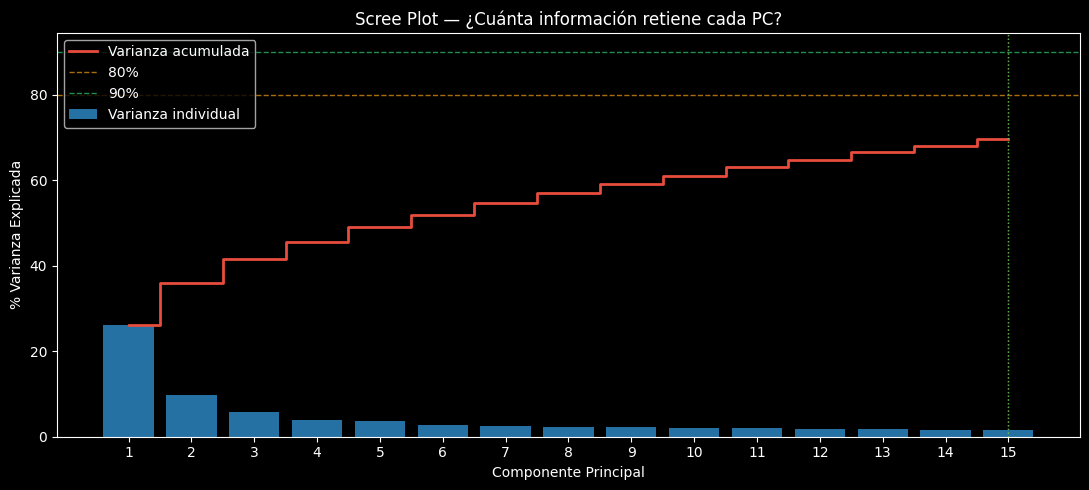

In [11]:
# ==========================================
# 5. SCREE PLOT (varianza explicada)
# ==========================================
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(range(1, N_COMPONENTS+1), expl_var, alpha=0.75, color='#3498db', label='Varianza individual')
ax.step(range(1, N_COMPONENTS+1), cum_var, where='mid', color='#e74c3c', linewidth=2, label='Varianza acumulada')

# Líneas de referencia
ax.axhline(80, color='#f39c12', linewidth=1, linestyle='--', alpha=0.7, label='80%')
ax.axhline(90, color='#2ecc71', linewidth=1, linestyle='--', alpha=0.7, label='90%')
ax.axvline(n_80, color='#f39c12', linewidth=1, linestyle=':', alpha=0.7)
ax.axvline(n_90, color='#2ecc71', linewidth=1, linestyle=':', alpha=0.7)

ax.set_xlabel('Componente Principal')
ax.set_ylabel('% Varianza Explicada')
ax.set_title('Scree Plot — ¿Cuánta información retiene cada PC?')
ax.set_xticks(range(1, N_COMPONENTS+1))
ax.legend()
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=120, bbox_inches='tight')
plt.show()

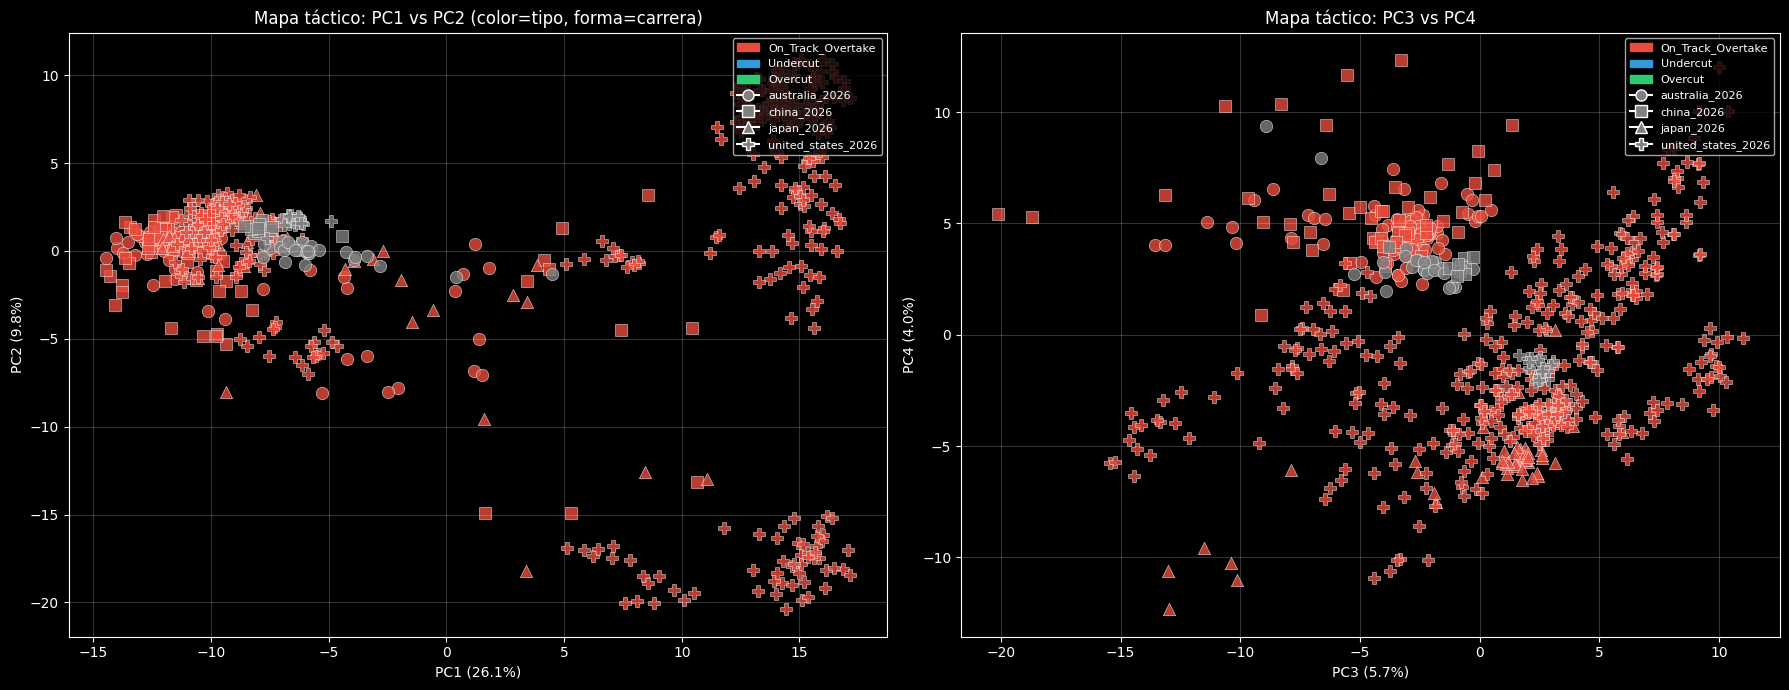

In [12]:
# ==========================================
# 6. SCATTER PC1 vs PC2 — coloreado por event_type
# ==========================================
df_viz = pd.DataFrame(X_pca[:, :4], columns=['PC1','PC2','PC3','PC4'])
df_viz = pd.concat([df_viz, metadata[['event_type','race_name']].reset_index(drop=True)], axis=1)

event_colors = {
    'On_Track_Overtake': '#e74c3c',
    'Undercut':          '#3498db',
    'Overcut':           '#2ecc71'
}

race_markers = {
    'australia_2026': 'o',
    'china_2026':     's',
    'japan_2026':     '^',
    'united_states_2026':     'P'  # <--- 'P' mayúscula: es un Plus relleno, compatible con edgecolors='w'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 6a. Por event_type
ax = axes[0]
for etype, grp in df_viz.groupby('event_type'):
    for race, sub in grp.groupby('race_name'):
        ax.scatter(
            sub['PC1'], sub['PC2'],
            c=event_colors.get(etype, 'gray'),
            marker=race_markers.get(race, 'o'),
            s=80, alpha=0.8, edgecolors='w', linewidths=0.4
        )

# Leyenda manual
type_patches = [mpatches.Patch(color=c, label=e) for e, c in event_colors.items()]
marker_handles = [plt.Line2D([0],[0], marker=m, color='w', markerfacecolor='gray', markeredgecolor='w',
                              markersize=8, label=r) for r, m in race_markers.items()]
ax.legend(handles=type_patches + marker_handles, loc='upper right', fontsize=8)
ax.set_xlabel(f'PC1 ({expl_var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({expl_var[1]:.1f}%)')
ax.set_title('Mapa táctico: PC1 vs PC2 (color=tipo, forma=carrera)')
ax.grid(True, alpha=0.2)

# 6b. PC3 vs PC4
ax = axes[1]
for etype, grp in df_viz.groupby('event_type'):
    for race, sub in grp.groupby('race_name'):
        ax.scatter(
            sub['PC3'], sub['PC4'],
            c=event_colors.get(etype, 'gray'),
            marker=race_markers.get(race, 'o'),
            s=80, alpha=0.8, edgecolors='w', linewidths=0.4
        )

ax.legend(handles=type_patches + marker_handles, loc='upper right', fontsize=8)
ax.set_xlabel(f'PC3 ({expl_var[2]:.1f}%)')
ax.set_ylabel(f'PC4 ({expl_var[3]:.1f}%)')
ax.set_title('Mapa táctico: PC3 vs PC4')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

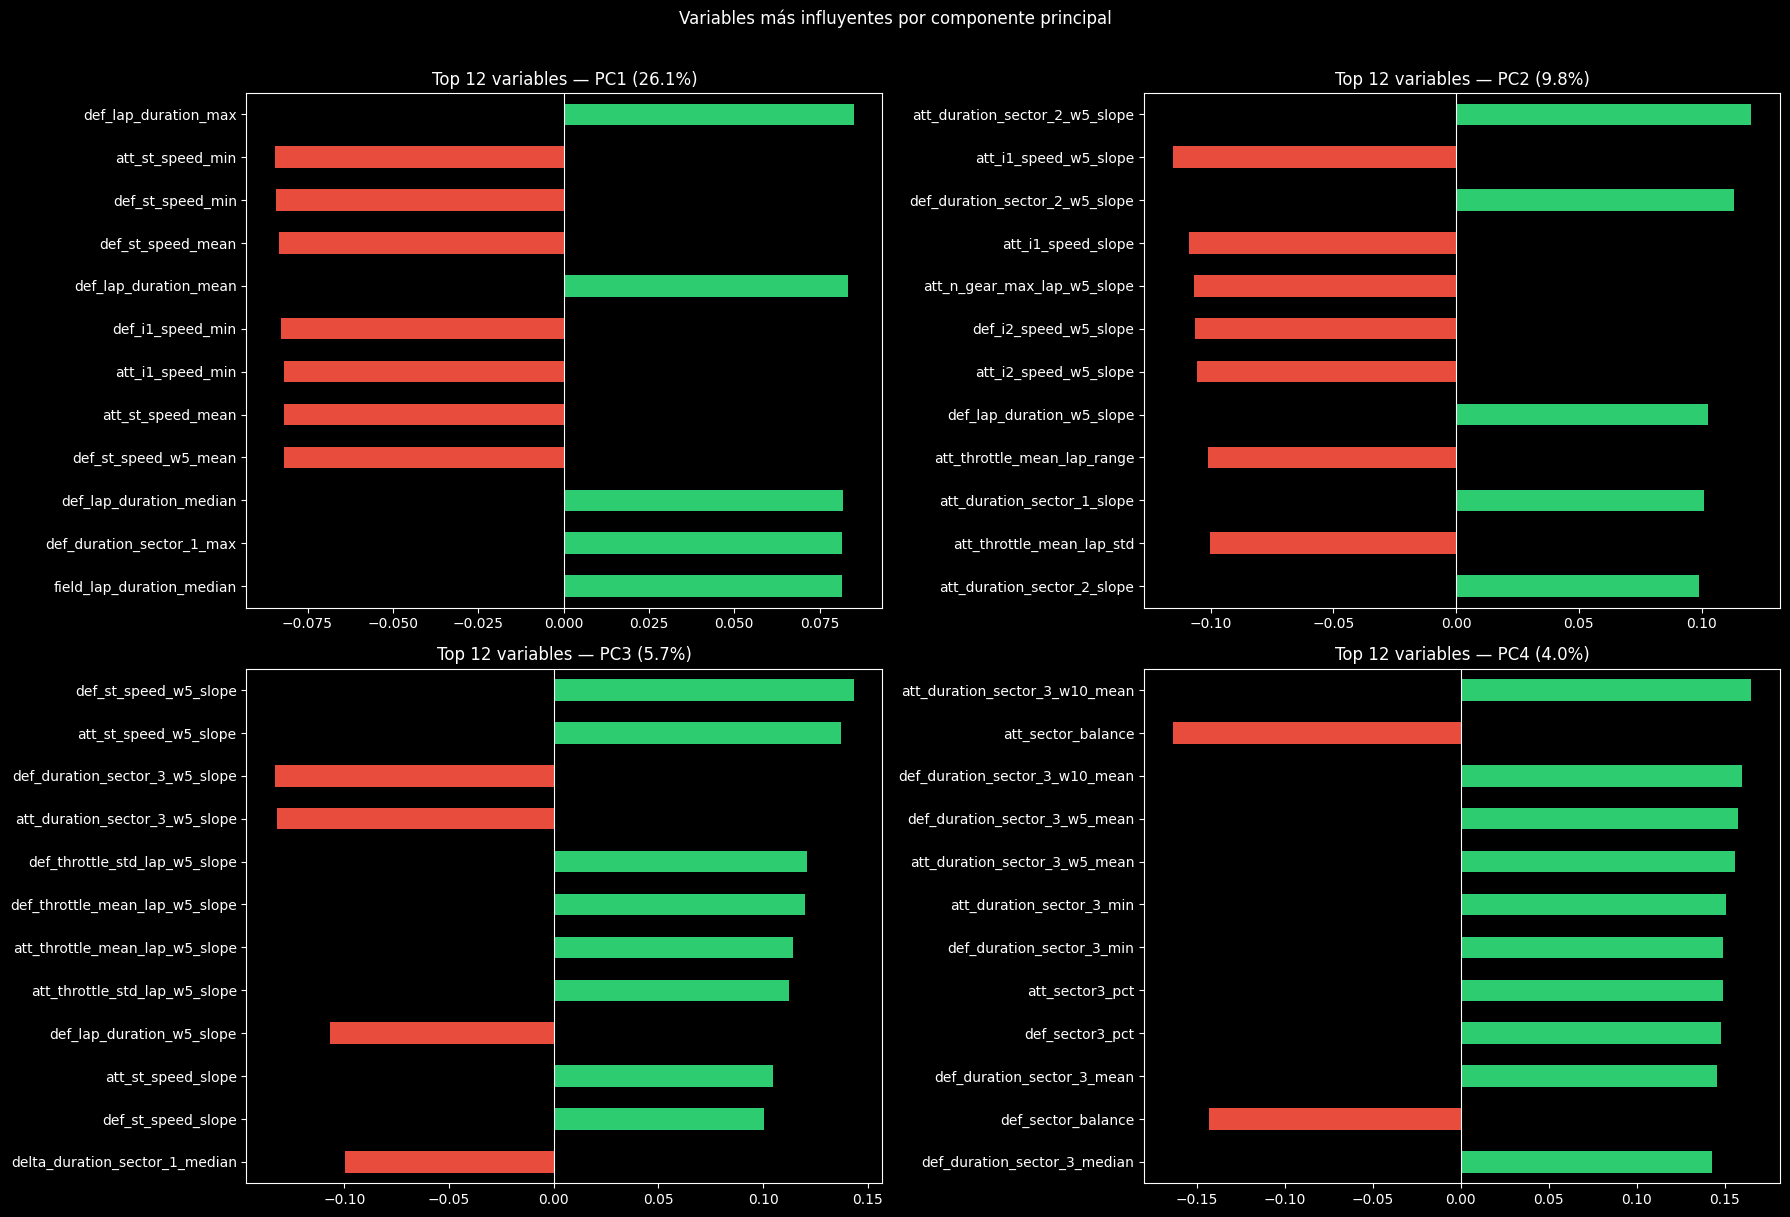

In [13]:
# ==========================================
# 7. LOADINGS — Top variables por PC
# ==========================================
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_clean,
    columns=[f'PC{i}' for i in range(1, N_COMPONENTS+1)]
)

def plot_top_loadings(pc_name, top_n=12, ax=None):
    top_vars   = loadings[pc_name].abs().sort_values(ascending=False).head(top_n)
    real_vals  = loadings.loc[top_vars.index, pc_name]
    colors     = ['#2ecc71' if x > 0 else '#e74c3c' for x in real_vals]

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    real_vals.plot(kind='barh', color=colors, ax=ax)
    ax.axvline(0, color='white', linewidth=0.8)
    ax.set_title(f'Top {top_n} variables — {pc_name} ({expl_var[int(pc_name[2:])-1]:.1f}%)')
    ax.invert_yaxis()

# PC1 a PC4 en una figura
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, pc in zip(axes.flatten(), ['PC1','PC2','PC3','PC4']):
    plot_top_loadings(pc, top_n=12, ax=ax)

plt.suptitle('Variables más influyentes por componente principal', y=1.01)
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=120, bbox_inches='tight')
plt.show()

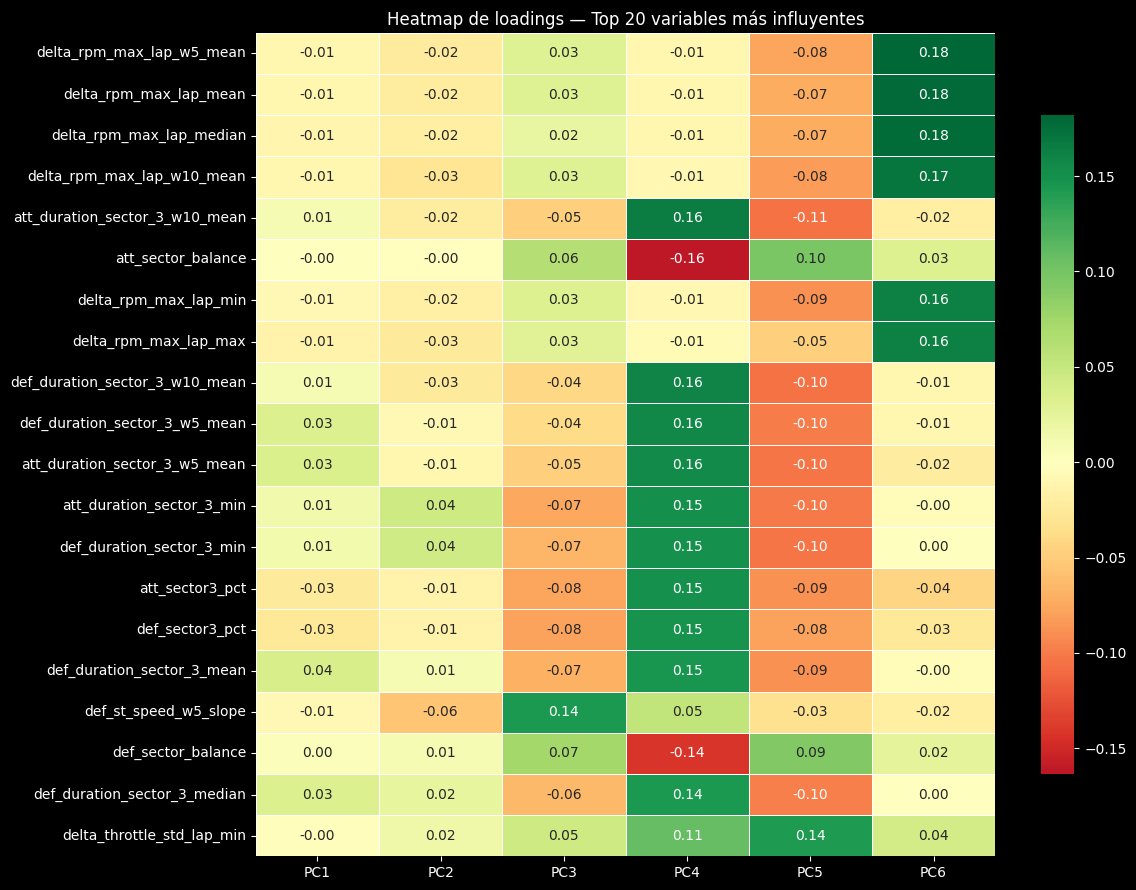

In [14]:
# ==========================================
# 8. HEATMAP DE LOADINGS (top 20 vars x PC1..PC6)
# ==========================================

# Seleccionamos las 20 variables con mayor loading absoluto en cualquier PC
top_vars_global = loadings.iloc[:, :6].abs().max(axis=1).sort_values(ascending=False).head(20).index
loadings_top    = loadings.loc[top_vars_global, [f'PC{i}' for i in range(1,7)]]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    loadings_top, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap de loadings — Top 20 variables más influyentes')
plt.tight_layout()
plt.savefig('pca_heatmap_loadings.png', dpi=120, bbox_inches='tight')
plt.show()

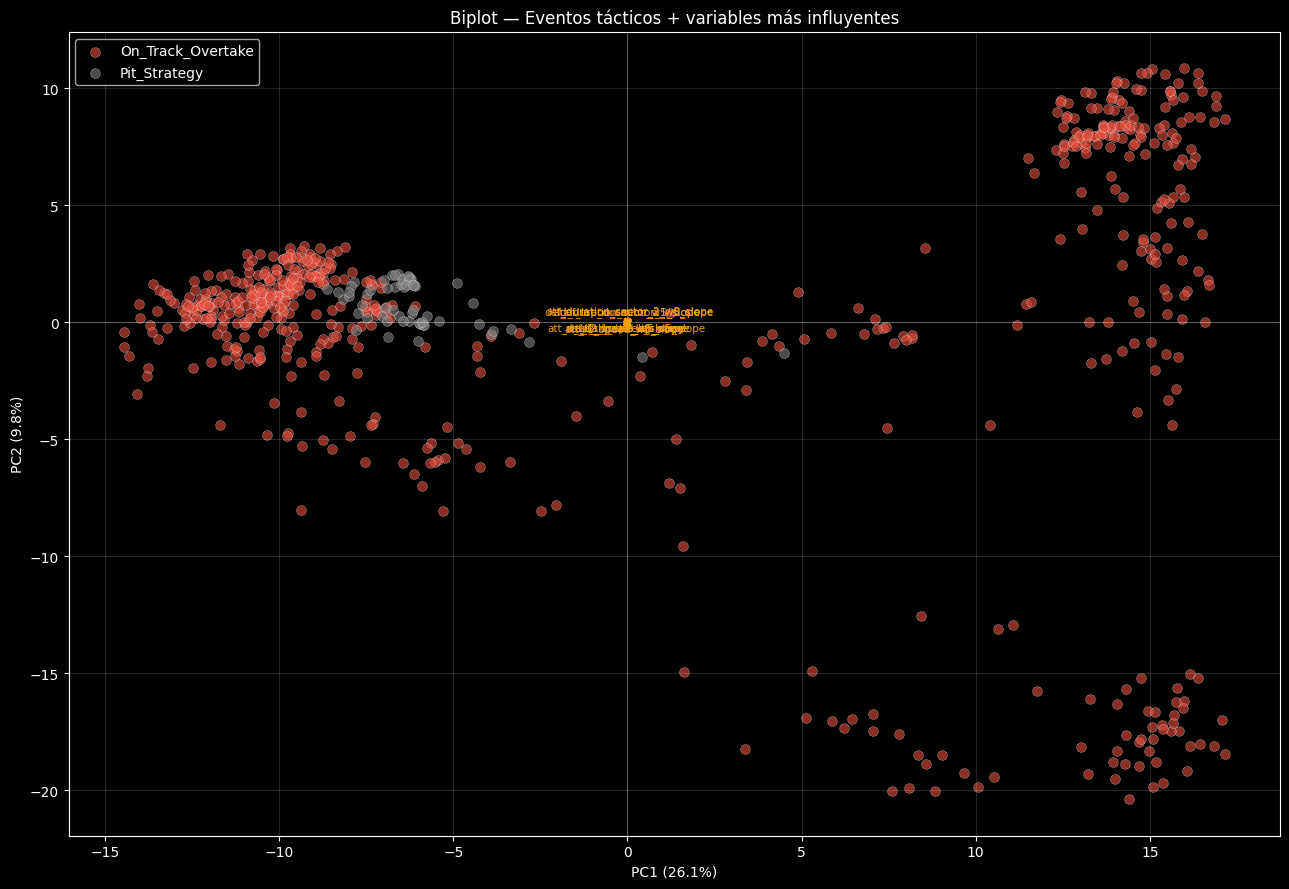

In [15]:
# ==========================================
# 9. BIPLOT (PC1 vs PC2 con vectores de variables)
# ==========================================
TOP_N_VECTORS = 10  # Cuántas variables mostrar como vectores

# Seleccionar las variables con mayor influencia en PC1 o PC2
top_biplot = loadings[['PC1','PC2']].apply(lambda x: x.abs()).max(axis=1)\
               .sort_values(ascending=False).head(TOP_N_VECTORS).index

fig, ax = plt.subplots(figsize=(13, 9))

# Puntos de eventos
for etype, grp in df_viz.groupby('event_type'):
    ax.scatter(grp['PC1'], grp['PC2'],
               c=event_colors.get(etype, 'gray'),
               s=50, alpha=0.6, label=etype, edgecolors='w', linewidths=0.3)

# Vectores de variables
scale = 3  # escalar los vectores para visibilidad
for var in top_biplot:
    vx = loadings.loc[var, 'PC1'] * scale
    vy = loadings.loc[var, 'PC2'] * scale
    ax.annotate('', xy=(vx, vy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#f39c12', lw=1.5))
    ax.text(vx * 1.08, vy * 1.08, var.replace('delta_','Δ').replace('_mean',''),
            fontsize=7.5, color='#f39c12', ha='center')

ax.axhline(0, color='white', linewidth=0.5, alpha=0.4)
ax.axvline(0, color='white', linewidth=0.5, alpha=0.4)
ax.set_xlabel(f'PC1 ({expl_var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({expl_var[1]:.1f}%)')
ax.set_title('Biplot — Eventos tácticos + variables más influyentes')
ax.legend()
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
# ==========================================
# 10. RESUMEN INTERPRETATIVO
# ==========================================
print('=' * 55)
print('RESUMEN DEL PCA')
print('=' * 55)
print(f'Dataset          : tactical_events_v3.parquet')
print(f'Eventos          : {len(df)}')
print(f'Features entrada : {X_raw.shape[1]}')
print(f'Features al PCA  : {len(feature_cols_clean)}')
print(f'Componentes calc : {N_COMPONENTS}')
print()
print('Varianza explicada por componente:')
for i, (ind, cum) in enumerate(zip(expl_var, cum_var)):
    bar = '█' * int(ind)
    print(f'  PC{i+1:2d}: {ind:5.2f}%  acum {cum:5.1f}%  {bar}')

print()
print('Top 5 variables por PC:')
for pc in ['PC1','PC2','PC3','PC4']:
    top5 = loadings[pc].abs().sort_values(ascending=False).head(5).index.tolist()
    print(f'  {pc}: {", ".join(top5)}')

RESUMEN DEL PCA
Dataset          : tactical_events_v3.parquet
Eventos          : 643
Features entrada : 498
Features al PCA  : 492
Componentes calc : 15

Varianza explicada por componente:
  PC 1: 26.08%  acum  26.1%  ██████████████████████████
  PC 2:  9.78%  acum  35.9%  █████████
  PC 3:  5.68%  acum  41.5%  █████
  PC 4:  3.96%  acum  45.5%  ███
  PC 5:  3.65%  acum  49.1%  ███
  PC 6:  2.82%  acum  52.0%  ██
  PC 7:  2.60%  acum  54.6%  ██
  PC 8:  2.34%  acum  56.9%  ██
  PC 9:  2.18%  acum  59.1%  ██
  PC10:  2.01%  acum  61.1%  ██
  PC11:  1.94%  acum  63.0%  █
  PC12:  1.81%  acum  64.9%  █
  PC13:  1.70%  acum  66.6%  █
  PC14:  1.58%  acum  68.1%  █
  PC15:  1.51%  acum  69.6%  █

Top 5 variables por PC:
  PC1: def_lap_duration_max, att_st_speed_min, def_st_speed_min, def_st_speed_mean, def_lap_duration_mean
  PC2: att_duration_sector_2_w5_slope, att_i1_speed_w5_slope, def_duration_sector_2_w5_slope, att_i1_speed_slope, att_n_gear_max_lap_w5_slope
  PC3: def_st_speed_w5_slop

In [18]:
# Notebook PCA — una línea
pd.DataFrame(X_pca, columns=[f'PC{i}' for i in range(1, N_COMPONENTS + 1)])\
  .assign(event_id=metadata['event_id'].values,
          race_name=metadata['race_name'].values,
          event_type=metadata['event_type'].values)\
  .to_parquet('../data/features/pca_scores.parquet', index=False)

# Notebook Clustering — dos líneas
df        = pd.read_parquet('../data/features/pca_scores.parquet')
X_cluster = df.filter(like='PC').values